In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding,Dense
from tensorflow.keras import Sequential
from sklearn.metrics import r2_score
import pandas as pd
print(tf.__version__)

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.15.0


In [4]:
#x=> datos

#y1= w1*x+b1
# y1 = funcion_no_lineal(y1)
#y1= BN(y1)
#y2= w2*y1 +b2

#y2= funcion_no_lineal(y2)
#y2 =BN(y2)=> normalizada

##y2=> prediccion ----> mse(y2, y_true)


In [5]:

#y2= w2*(w1*x+b1)+b2 = w2*w1*x +w2*b1+b2=> w3*x+b3 

#w3=w2*w1

#b3= w2*b1+b2

## Funciones de activacion:
https://www.tensorflow.org/api_docs/python/tf/keras/activations


In [62]:
inputs = tf.constant([x for x in range(-10, 20)],tf.float64)

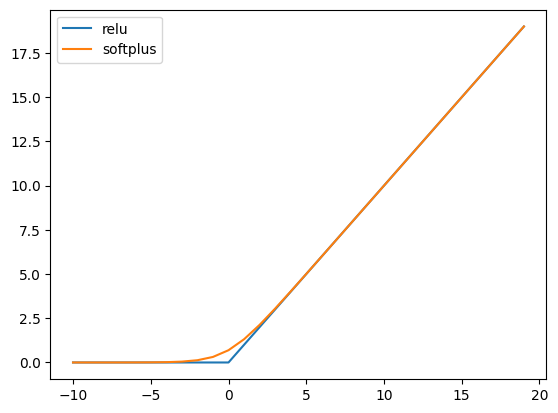

In [63]:
plt.plot(inputs,tf.keras.activations.relu(inputs),label='relu')

plt.plot(inputs,tf.keras.activations.softplus(inputs),label='softplus')

plt.legend()

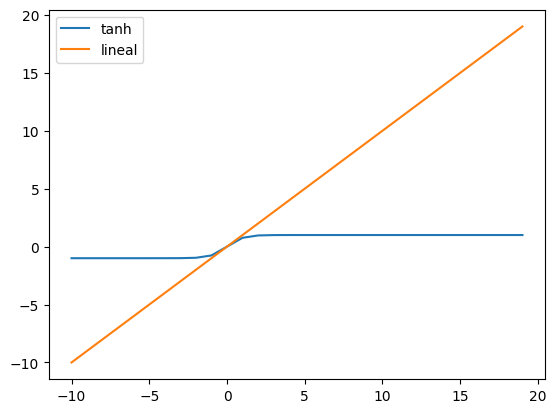

In [8]:
plt.plot(inputs,tf.keras.activations.tanh(inputs),label='tanh')
plt.plot(inputs,tf.keras.activations.linear(inputs),label='lineal')
plt.legend()

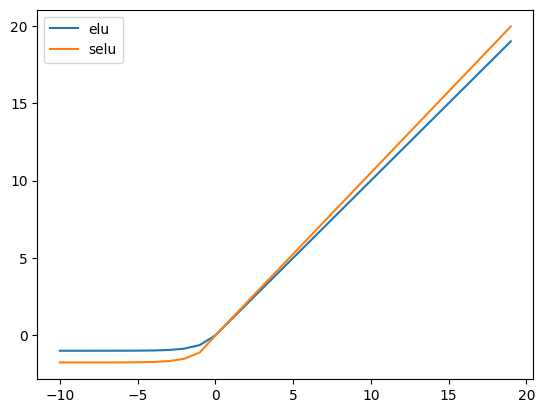

In [9]:
plt.plot(inputs,tf.keras.activations.elu(inputs),label='elu')
plt.plot(inputs,tf.keras.activations.selu(inputs),label='selu')
plt.legend()

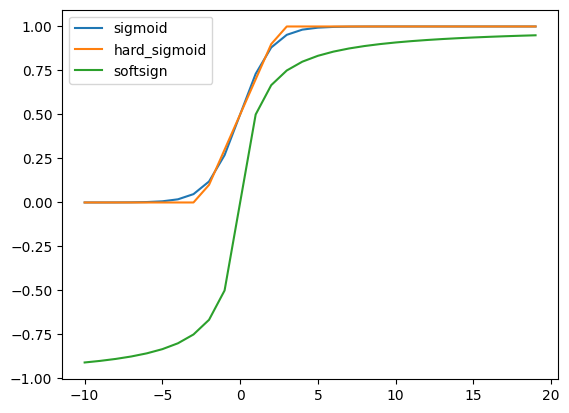

In [10]:
plt.plot(inputs,tf.keras.activations.sigmoid(inputs),label='sigmoid')
plt.plot(inputs,tf.keras.activations.hard_sigmoid(inputs),label='hard_sigmoid')
plt.plot(inputs,tf.keras.activations.softsign(inputs),label='softsign')
plt.legend()

In [11]:
z = tf.Variable(np.array([[1,1.2,1.8,2],[3,4.2,5.8,9]]), dtype = tf.float32)
tf.keras.activations.softmax(z, axis = 1)

<tf.Tensor: shape=(2, 4), dtype=float32, numpy=
array([[0.13956296, 0.17046258, 0.31060302, 0.37937143],
       [0.00235741, 0.00782689, 0.03876686, 0.9510488 ]], dtype=float32)>

## Metodos para ayudar a mejor convergencia:
    1- tf.keras.layers.BatchNormalization(
    axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
    beta_initializer='zeros', gamma_initializer='ones',
    moving_mean_initializer='zeros',
    moving_variance_initializer='ones', beta_regularizer=None,
        gamma_regularizer=None, beta_constraint=None, gamma_constraint=None, **kwargs)\\
https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization
    
    2- Inicializadores: 
https://www.tensorflow.org/api_docs/python/tf/keras/initializers


## Overfitting & Underfitting

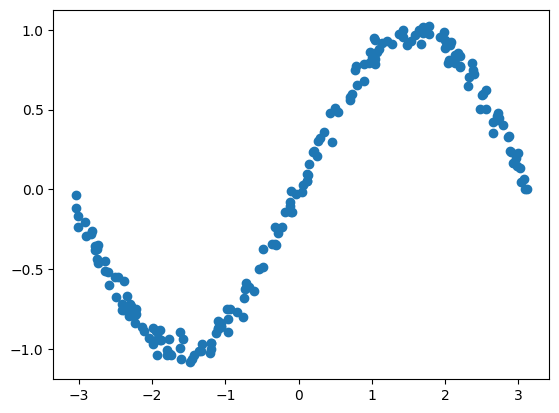

In [12]:
N = 200
xs = np.array(sorted(np.random.uniform(size=N, low=-np.pi, high=np.pi)))
ys = np.sin(xs) + np.random.normal(loc=0, scale=0.05, size=N)
plt.figure()
plt.scatter(xs, ys)

In [13]:
## Tomado de: https://github.com/cbonitz/overfitting-underfitting/blob/master/Overfitting_Underfitting.ipynb
class Normalizer:
    """SKLearn-style normalizer normalizing values to [-1, 1]"""
    def fit(self, xs):
        self.mean = np.mean(xs)
        self.width = np.max(xs) - np.min(xs)
    def transform(self, xs):
        return (xs - self.mean) / self.width

    
class PolynomialRegression:
    """SKLearn-style polynomial regression function"""
    def __init__(self, degree=3, alpha=0.01, epochs=100):
        self.degree = degree
        self.alpha = alpha
        self.epochs = epochs
    
    
    
    
    def fit(self, xs, ys):
        def poly(x,a_list):
            #self.x =x
            #self.a_list=a_list
            ans = 0
            for n,a in enumerate(a_list):
                ans += a*x**n
            return ans
        coeffs = np.random.normal(0, 0.01, size=self.degree + 1)
        for i in range(self.epochs):
            yhats = poly(xs, coeffs)
            err = (yhats-ys).reshape(-1, 1)
            exponents=np.arange(0, len(coeffs)).reshape(1, -1)
            powers = np.power(xs.reshape(-1, 1), exponents)
            dcoeffs = -self.alpha * np.mean(np.multiply(powers, err), axis=0)
            coeffs += dcoeffs
        self.coeffs = coeffs
        return coeffs

    def predict(self, xs):
        return np.polynomial.polynomial.polyval(xs, self.coeffs)

def plot_result(xs, ys, normalizer, predictor, what_we_are_showing):
    """Plot a result"""
    plt.figure()
    xs_display = np.linspace(xs.min(), xs.max(), N)
    xhats_display = normalizer.transform(xs_display)
    yhats = predictor.predict(xhats_display)
    plt.scatter(xs, ys, label="data")
    plt.plot(xs_display, yhats, label="prediction")
    plt.title("Curve fit using {} points of training data\nPredictions for {}"
                  .format(len(xs), what_we_are_showing))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
def train_on(xs, ys, degree=3, n=N):
    """Run an experiment of fitting a polynomial of degree degree to n data points"""
    if n == N:
        train_indices = np.arange(N)
    else:
        train_indices = sorted(np.random.choice(N, n))
    xs_train = np.take(xs, train_indices)
    ys_train = np.take(ys, train_indices)
    normalizer = Normalizer()
    normalizer.fit(xs_train)
    xhats_train = normalizer.transform(xs_train)
    p = PolynomialRegression(degree=degree, alpha=1.0, epochs=20000)
    coeffs = p.fit(xhats_train, ys_train)
    plot_result(xs_train, ys_train, normalizer, p, "training data")
    
    if n == N:
        plot_result(xs, ys, normalizer, p, "all data")
    else:
        xs_test = np.delete(xs, train_indices)
        ys_test = np.delete(ys, train_indices)
        plot_result(xs_test, ys_test, normalizer, p, "test data")

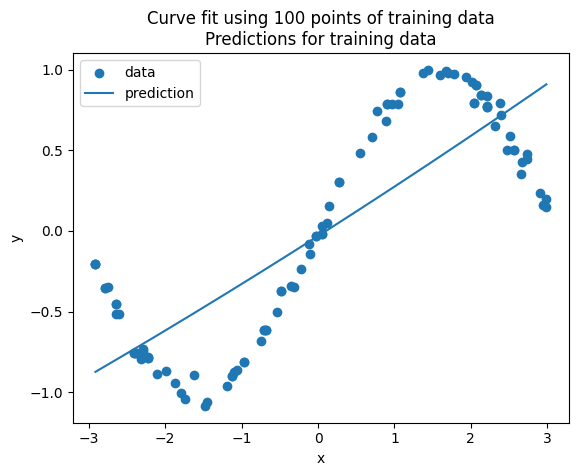

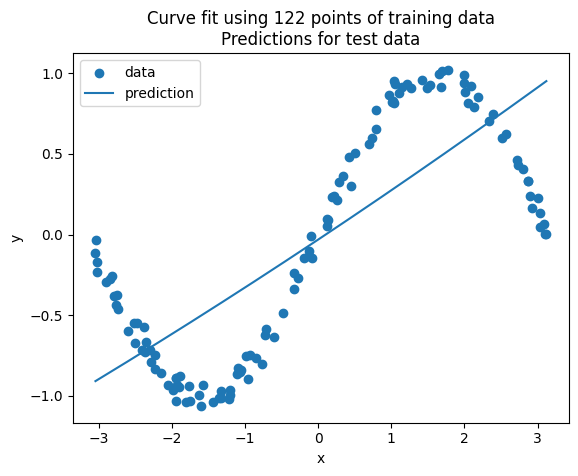

In [14]:
train_on(xs, ys, degree=2, n=100)

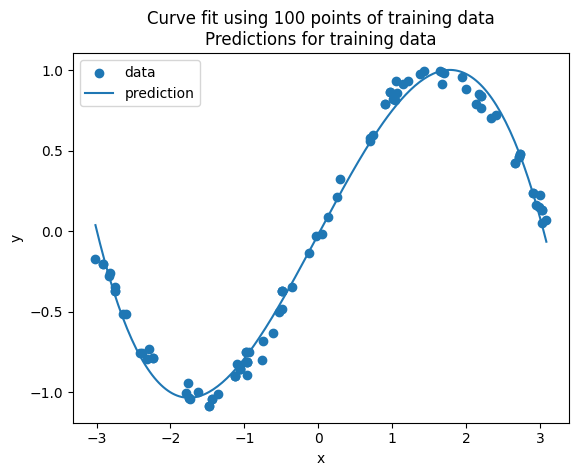

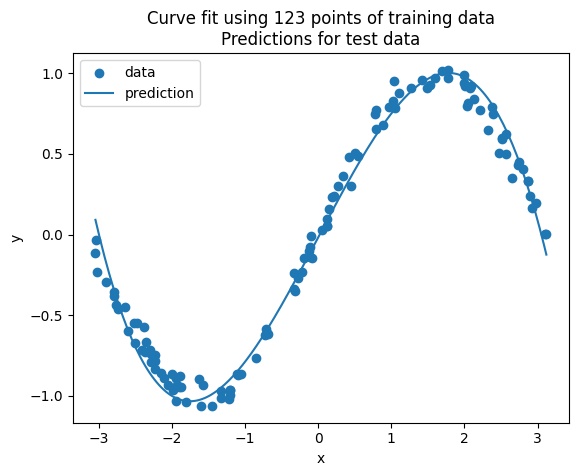

In [15]:
train_on(xs, ys, degree=20, n=100)

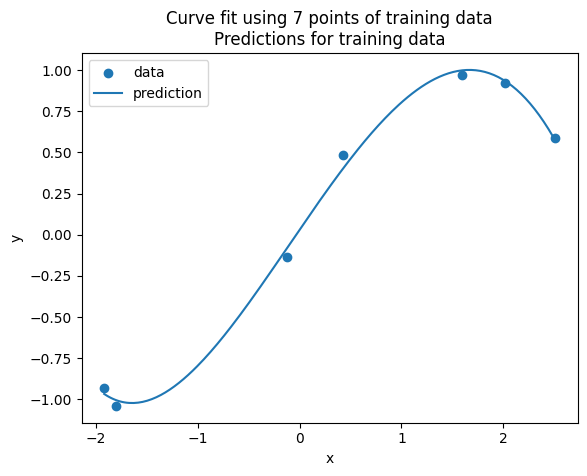

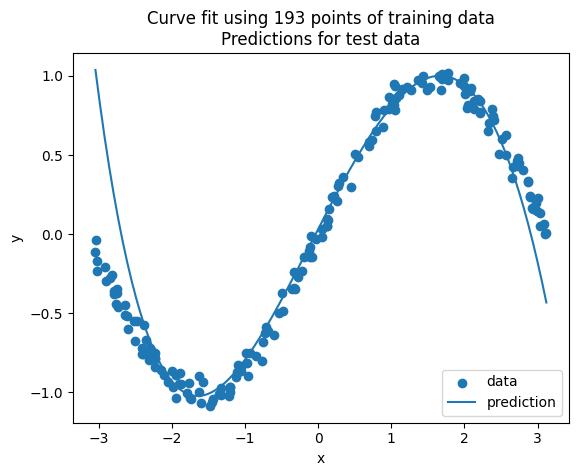

In [16]:
train_on(xs, ys, degree=20, n=7)

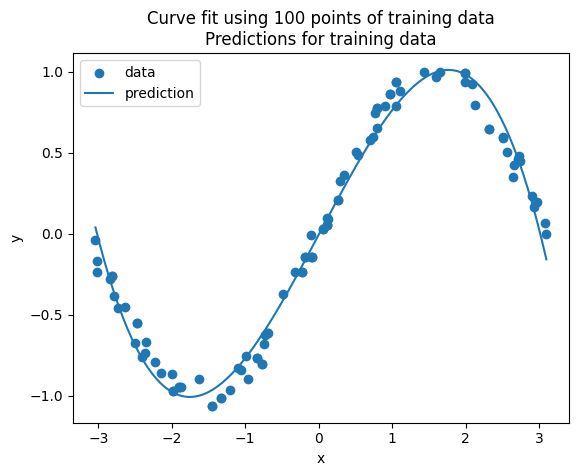

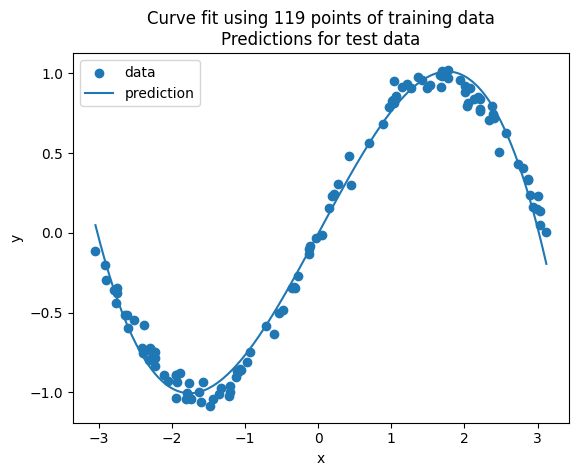

In [18]:
train_on(xs, ys, degree=100, n=100)

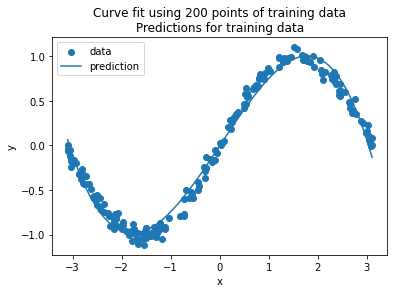

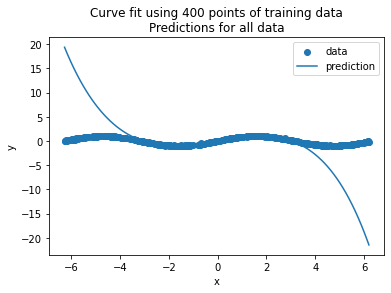

In [ ]:
xs_left = np.array(sorted(np.random.uniform(size=int(N/2), low=-2*np.pi, high=-np.pi)))
xs_right = np.array(sorted(np.random.uniform(size=int(N/2), low=np.pi, high=2*np.pi)))
ys_left = np.sin(xs_left) + np.random.normal(loc=0, scale=0.05, size=len(xs_left))
ys_right = np.sin(xs_right) + np.random.normal(loc=0, scale=0.05, size=len(xs_right))
xs_all = np.concatenate([xs_left, xs, xs_right])
ys_all = np.concatenate([ys_left, ys, ys_right])

normalizer = Normalizer()
normalizer.fit(xs)
xhats = normalizer.transform(xs)
p = PolynomialRegression(degree=20, alpha=1.0, epochs=20000)
coeffs = p.fit(xhats, ys)
plot_result(xs, ys, normalizer, p, "training data")
plot_result(xs_all, ys_all, normalizer, p, "all data")

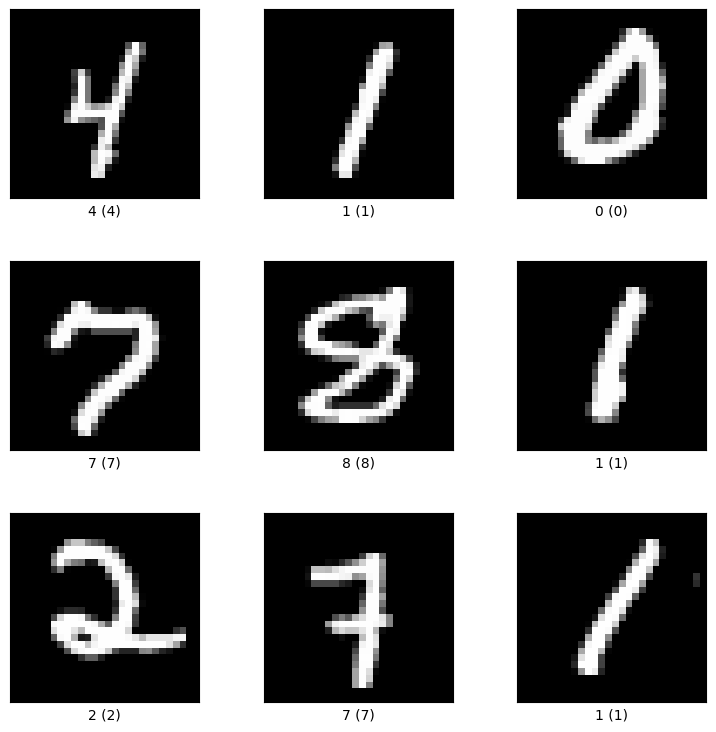

In [66]:

(ds_train_mnist, ds_test_mnist), ds_info_mnist = tfds.load(
    name = 'mnist',
    split=['train[:10%]', 'test[:10%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True)
fig = tfds.show_examples(ds_train_mnist, ds_info_mnist)

In [73]:
def one_hot(dx,dy):
    return dx, tf.one_hot(dy, 10)

def data_load_sequential(data_ds,shuffle_train=True ,batch_=5):
    data_ds=data_ds.map(one_hot)
    data_ds = data_ds.cache()
    if shuffle_train:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

data_train_mnist = data_load_sequential(ds_train_mnist)
data_test_mnist = data_load_sequential(ds_test_mnist,shuffle_train=False)
for ds,lb in data_train_mnist.take(1):
    print(ds.shape,lb)
shaped_mnist=ds[0].numpy().shape




trainprocess = Sequential([                
        #layers.Rescaling(scale=1.0 / 255),
        layers.Flatten()
    ],name='preprocess')

(5, 28, 28, 1) tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]], shape=(5, 10), dtype=float32)


In [74]:
shaped_mnist

(28, 28, 1)

In [75]:
###Flatten!
# 0001000 =>0001000000100000010000001000
# 0001000
# 0001000
# 0001000


In [76]:
from tensorflow.keras import regularizers

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=shaped_mnist))
model.add(trainprocess)
model.add(layers.Dense(512,activation='relu',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Dense(10,activation='softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 preprocess (Sequential)     (None, 784)               0         
                                                                 
 dense_7 (Dense)             (None, 512)               401920    
                                                                 
 dense_8 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407050 (1.55 MB)
Trainable params: 407050 (1.55 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [77]:
model.compile(loss='CategoricalCrossentropy',
              optimizer='adam',metrics=['accuracy'])

history=model.fit(data_train_mnist,validation_data=data_test_mnist, epochs=10,verbose=1)

Epoch 1/10
1200/1200 [==============================] - 7s 5ms/step - loss: 11.7634 - accuracy: 0.8187 - val_loss: 3.8216 - val_accuracy: 0.8600
Epoch 2/10
1200/1200 [==============================] - 6s 5ms/step - loss: 1.7768 - accuracy: 0.9003 - val_loss: 2.1364 - val_accuracy: 0.8780
Epoch 3/10
1200/1200 [==============================] - 6s 5ms/step - loss: 1.6633 - accuracy: 0.9053 - val_loss: 2.1351 - val_accuracy: 0.8760
Epoch 4/10
1200/1200 [==============================] - 6s 5ms/step - loss: 1.5970 - accuracy: 0.9137 - val_loss: 1.8410 - val_accuracy: 0.9090
Epoch 5/10
1200/1200 [==============================] - 6s 5ms/step - loss: 1.3541 - accuracy: 0.9178 - val_loss: 2.3871 - val_accuracy: 0.8940
Epoch 6/10
1200/1200 [==============================] - 6s 5ms/step - loss: 1.1077 - accuracy: 0.9313 - val_loss: 1.8601 - val_accuracy: 0.9030
Epoch 7/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.7506 - accuracy: 0.9422 - val_loss: 2.4084 - val_accuracy

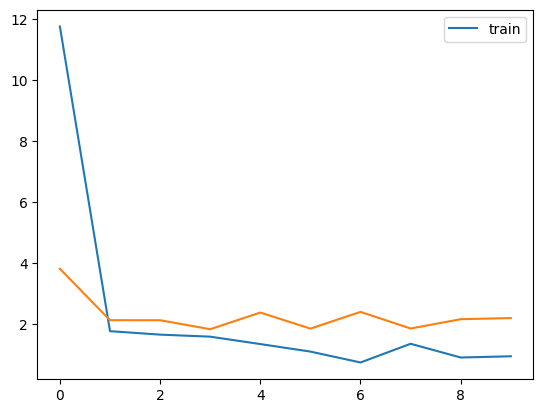

In [78]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'])
plt.legend()

## - L2 Regularizacion

Permite evitar overfitting. Se realiza a traves de la modificacion de la funcion de costo:
- **clasificacion**
$$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} \tag{1}$$
modificada a:
$$J_{regul} = \small \underbrace{-\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} }_\text{cross-entropy} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2} }_\text{L2 regularizacion costo} \tag{2}$$

- **regresion**
$$J = \frac{1}{m} \sum\limits_{i = 1}^{m}  \large{(}\small  y^{(i)} -a^{[L](i)}\large{)}^2 \tag{1}$$
modificada a:
$$J_{regul} = \small \underbrace{\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)} -a^{[L](i)}\large{)}^2 }_\text{mse} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2} }_\text{L2 regularizacion costo} \tag{2}$$


## - L1 Regularizacion

Permite evitar overfitting. Se realiza a traves de la modificacion de la funcion de costo:
- **clasificacion**
$$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} \tag{1}$$
modificada a:
$$J_{regul} = \small \underbrace{-\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} }_\text{cross-entropy} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]} }_\text{L2 regularizacion costo} \tag{2}$$

- **regresion**
$$J = \frac{1}{m} \sum\limits_{i = 1}^{m}  \large{(}\small  y^{(i)} -a^{[L](i)}\large{)}^2 \tag{1}$$
modificada a:
$$J_{regul} = \small \underbrace{\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)} -a^{[L](i)}\large{)}^2 }_\text{mse} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]} }_\text{L2 regularizacion costo} \tag{2}$$

## - L1-L2 Regularizacion

Permite evitar overfitting. Se realiza a traves de la modificacion de la funcion de costo:
- **clasificacion**
$$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} \tag{1}$$
modificada a:
$$J_{regul} = \small \underbrace{-\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} }_\text{cross-entropy} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]}+\frac{1}{m} \frac{\lambda_1}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2} }_\text{L2 regularizacion costo} \tag{2}$$

- **regresion**
$$J = \frac{1}{m} \sum\limits_{i = 1}^{m}  \large{(}\small  y^{(i)} -a^{[L](i)}\large{)}^2 \tag{1}$$
modificada a:
$$J_{regul} = \small \underbrace{\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)} -a^{[L](i)}\large{)}^2 }_\text{mse} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]} +\frac{1}{m} \frac{\lambda_1}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2}}_\text{L2 regularizacion costo} \tag{2}$$

In [13]:
# from tensorflow.keras import layers
# from tensorflow.keras import regularizers

# layer = layers.Dense(
#     units=64,
#     kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4),
#     bias_regularizer=regularizers.l2(1e-4),
#     activity_regularizer=regularizers.l1(1e-5))

## - Dropout Regularizacion

Permite evitar overfitting. Se realiza desconectando conexiones entre neuronas:

    - tf.keras.layers.Dropout(
       rate, noise_shape=None, seed=None, **kwargs)
    - rate: Float between 0 and 1. Fraction of the input units to drop

In [79]:
tf.keras.backend.clear_session()
model1 = tf.keras.Sequential()
model1.add(tf.keras.Input(shape=shaped_mnist))
model1.add(trainprocess)
model1.add(layers.Dense(256,activation='relu'))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.2))
model1.add(layers.Dense(128,activation='relu'))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.2))
model1.add(layers.Dense(64,activation='relu'))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.2))

model1.add(layers.Dense(10,activation='softmax'))
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 preprocess (Sequential)     (None, 784)               0         
                                                                 
 dense (Dense)               (None, 256)               200960    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                       

In [82]:
model1.compile(loss='CategoricalCrossentropy',
              optimizer='adam',metrics=['accuracy'])

history1=model1.fit(data_train_mnist,validation_data=data_test_mnist, epochs=2,verbose=1)

Epoch 1/2
1200/1200 [==============================] - 6s 4ms/step - loss: 0.7701 - accuracy: 0.7507 - val_loss: 0.3260 - val_accuracy: 0.9090
Epoch 2/2
1200/1200 [==============================] - 5s 4ms/step - loss: 0.7202 - accuracy: 0.7742 - val_loss: 0.2958 - val_accuracy: 0.9130


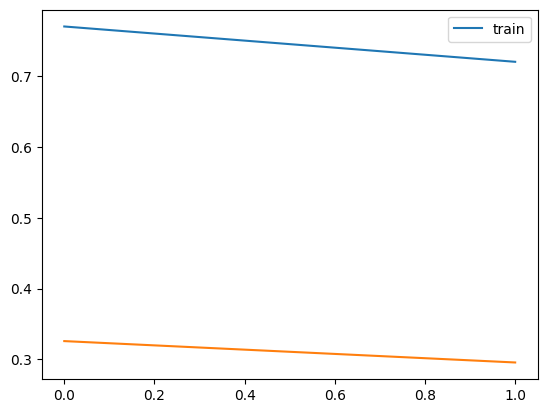

In [83]:
plt.plot(history1.history['loss'],label='train')
plt.plot(history1.history['val_loss'])
plt.legend()

## Compile en Keras:

In [1]:
# Model.compile(
#     optimizer="rmsprop",
#     loss=None,
#     metrics=None,
#     loss_weights=None,
#     weighted_metrics=None,
#     run_eagerly=None,
#     steps_per_execution=None,
#     jit_compile=None,
#     **kwargs)

###ejemplo

# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#               loss=tf.keras.losses.BinaryCrossentropy(),
#               metrics=[tf.keras.metrics.BinaryAccuracy(),
#                        tf.keras.metrics.FalseNegatives()])


## loss = fn(y_true, y_pred)  tf.keras.losses. ; If the model has multiple outputs, you can use a different loss on each output by passing a dictionary or a list of losses.
##  optimizer= String (name of optimizer) or optimizer instance. See tf.keras.optimizers.
## metrics= See tf.keras.metrics. Typically you will use metrics=['accuracy']. A function is any callable with the signature result = fn(y_true, y_pred)

## Fit en Keras

In [2]:
# Model.fit(
#     x=None,
#     y=None,
#     batch_size=None,
#     epochs=1,
#     verbose="auto",
#     callbacks=None,
#     validation_split=0.0,
#     validation_data=None,
#     shuffle=True,
#     class_weight=None,
#     sample_weight=None,
#     initial_epoch=0,
#     steps_per_epoch=None,
#     validation_steps=None,
#     validation_batch_size=None,
#     validation_freq=1,
#     max_queue_size=10,
#     workers=1,
#     use_multiprocessing=False,)


In [ ]:
#x,y = (inputs, targets) 
# verbose= 'auto', 0, 1, or 2. Verbosity mode. 0 = silent, 1 = progress bar, 2 = one line per epoch.

## evaluate  y predict en keras

In [34]:
# Model.evaluate(
#     x=None,
#     y=None,
#     batch_size=None,
#     verbose=1,
#     sample_weight=None,
#     steps=None,
#     callbacks=None,
#     max_queue_size=10,
#     workers=1,
#     use_multiprocessing=False,
#     return_dict=False)


# Model.predict(
#     x,
#     batch_size=None,
#     verbose=0,
#     steps=None,
#     callbacks=None,
#     max_queue_size=10,
#     workers=1,
#     use_multiprocessing=False,)

In [84]:
tf.keras.backend.clear_session()
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=shaped_mnist))
model.add(trainprocess)
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 preprocess (Sequential)     (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [85]:
model.compile(loss='CategoricalCrossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),metrics=['accuracy'])

In [87]:
history=model.fit(data_train_mnist,validation_data=data_test_mnist,steps_per_epoch=100, epochs=3,verbose='auto')

Epoch 1/3
100/100 [==============================] - 1s 5ms/step - loss: 4.3664 - accuracy: 0.7660 - val_loss: 4.2427 - val_accuracy: 0.8040
Epoch 2/3
100/100 [==============================] - 1s 5ms/step - loss: 3.3907 - accuracy: 0.7920 - val_loss: 3.2075 - val_accuracy: 0.8180
Epoch 3/3
100/100 [==============================] - 1s 5ms/step - loss: 3.7526 - accuracy: 0.7860 - val_loss: 3.4252 - val_accuracy: 0.8210


In [88]:
history.epoch,history.params

([0, 1, 2], {'verbose': 1, 'epochs': 3, 'steps': 100})

In [89]:
history.history

{'loss': [4.366400241851807, 3.390693187713623, 3.7526161670684814],
 'accuracy': [0.765999972820282, 0.7919999957084656, 0.7860000133514404],
 'val_loss': [4.242721080780029, 3.20749568939209, 3.4252076148986816],
 'val_accuracy': [0.8040000200271606, 0.8180000185966492, 0.8209999799728394]}

In [90]:
model.evaluate(data_test_mnist) ##evaluate

  1/200 [..............................] - ETA: 3s - loss: 4.7684e-07 - accuracy: 1.0000

200/200 [==============================] - 0s 2ms/step - loss: 3.4252 - accuracy: 0.8210


[3.4252076148986816, 0.8209999799728394]

In [91]:
for img, label in data_test_mnist.take(1):
    print(img.shape)

(5, 28, 28, 1)


In [92]:
one_image=img[1:2]
one_image.shape

TensorShape([1, 28, 28, 1])

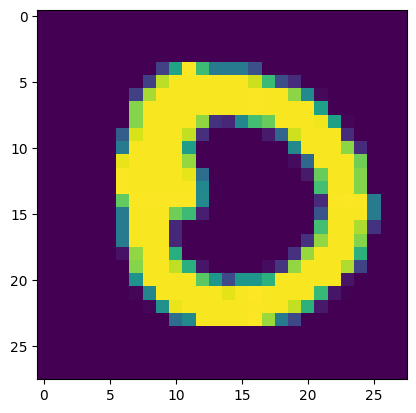

In [93]:
plt.imshow(one_image[0])

In [94]:
prediction = model1.predict(one_image) ##Predict
print(prediction)

1/1 [==============================] - 0s 108ms/step
[[9.9694186e-01 4.7824346e-07 3.1502094e-04 5.4526013e-06 8.6793581e-05
  9.7459700e-04 2.5616100e-04 1.4144867e-06 1.4016889e-03 1.6630009e-05]]


In [96]:
sum(prediction[0])

1.0000001012571147

In [97]:
np.argmax(prediction)

0

## Guardar modelos en Tf

In [ ]:
## Guardar el modelo y cargarlo de nuevo:

# Model.save(
#     filepath,
#     overwrite=True,
#     include_optimizer=True,
#     save_format=None,
#     signatures=None,
#     options=None,
#     save_traces=True)


# tf.keras.models.load_model(
#     filepath, custom_objects=None, compile=True, options=None)


## Guardar solo los parametros y cargarlos de nuevo:

#Model.save_weights(filepath, overwrite=True, save_format=None, options=None)

#Model.load_weights(filepath, by_name=False, skip_mismatch=False, options=None)

In [99]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 preprocess (Sequential)     (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [100]:
from tensorflow.keras.models import load_model

model.save('modelo_clase_6.h5')

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
del model  

In [103]:
model = load_model('modelo_clase_6.h5')

In [104]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 preprocess (Sequential)     (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [105]:
prediction = model.predict(one_image) ##Predict
print(prediction)
np.argmax(prediction)

1/1 [==============================] - 0s 63ms/step
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


0

In [106]:
model.evaluate(data_test_mnist)

200/200 [==============================] - 0s 2ms/step - loss: 3.4252 - accuracy: 0.8210


[3.4252076148986816, 0.8209999799728394]

In [107]:
model.save_weights('tf_saved_model')

In [109]:
model

NameError: name 'model' is not defined

In [110]:
tf.keras.backend.clear_session()
model1 = tf.keras.Sequential()
model1.add(tf.keras.Input(shape=shaped_mnist))
model1.add(trainprocess)
model1.add(layers.Dense(128,activation='relu'))
model1.add(layers.Dense(64,activation='relu'))
model1.add(layers.Dense(10,activation='softmax'))
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 preprocess (Sequential)     (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [113]:
model1.load_weights('tf_saved_model')

In [114]:
model1.compile(loss='CategoricalCrossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),metrics=['accuracy'])
model1.evaluate(data_test_mnist) ##evaluate

200/200 [==============================] - 0s 2ms/step - loss: 3.4252 - accuracy: 0.8210


[3.4252076148986816, 0.8209999799728394]

## Callbacks https://keras.io/api/callbacks/

In [57]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=2,monitor="val_loss", mode="min"),
    tf.keras.callbacks.ModelCheckpoint(filepath='carpeta_resultados/model.{epoch:02d}-{val_loss:.2f}.h5'),
    tf.keras.callbacks.TensorBoard(log_dir='carpeta_resultados/logs', histogram_freq=1),
]
model1.fit(data_train_mnist, epochs=3, validation_data=data_test_mnist, callbacks=my_callbacks)

Epoch 1/3
1200/1200 [==============================] - 4s 3ms/step - loss: 2.0120 - accuracy: 0.7490 - val_loss: 1.0708 - val_accuracy: 0.7010


c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/3
1200/1200 [==============================] - 4s 3ms/step - loss: 0.7028 - accuracy: 0.8118 - val_loss: 0.6842 - val_accuracy: 0.7830
Epoch 3/3
1200/1200 [==============================] - 3s 3ms/step - loss: 0.6212 - accuracy: 0.8352 - val_loss: 0.6098 - val_accuracy: 0.8490


In [60]:
# %load_ext tensorboard
# %tensorboard  --logdir carpeta_resultados/logs

## Ejemplo. Series de tiempo

In [15]:
df = pd.read_csv(r'C:\Users\javier\Documents\2025_nn\introduction_neural_networks\clases\Sunspots_.csv', index_col=0)
df.head(0)

,Date,Monthly Mean Total Sunspot Number


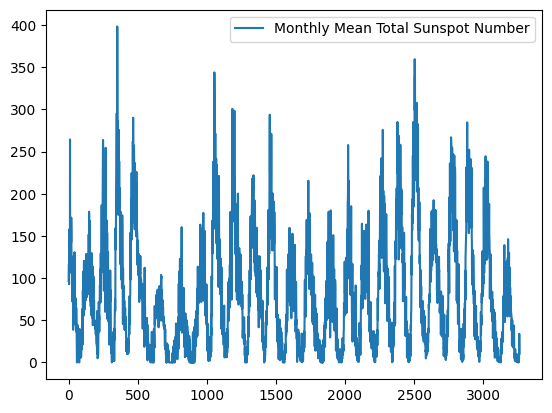

In [16]:
df.plot()
plt.show()

In [17]:
time_index = np.array(df['Date'])
data = np.array(df['Monthly Mean Total Sunspot Number'])
print(time_index.shape)
print(data.shape)

(3265,)
(3265,)


In [18]:
##Hiperparametros
SPLIT_TEST_TRAIN = 0.8
WINDOW_SIZE = 60
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

In [19]:
split_index = int(SPLIT_TEST_TRAIN * data.shape[0])
print(split_index)

2612


In [20]:
train_data = data[:split_index]
train_time = time_index[:split_index]

test_data = data[split_index:]
test_time = time_index[split_index:]

In [21]:
def ts_data_timeseries(data, window_size, batch_size):
  
  ds = tf.data.Dataset.from_tensor_slices(data)
  ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda window: window.batch(window_size + 1))
  ds = ds.map(lambda window: (window[:-1], window[-1]))
  ds = ds.batch(batch_size).prefetch(1)
  return ds

In [22]:
train_dataset = ts_data_timeseries(train_data, WINDOW_SIZE, BATCH_SIZE)
test_dataset = ts_data_timeseries(test_data, WINDOW_SIZE, BATCH_SIZE)

In [23]:
 for ds in train_dataset.take(1):
        print(ds)

(<tf.Tensor: shape=(32, 60), dtype=float64, numpy=
array([[ 96.7, 104.3, 116.7, ...,  41.7,  33.3,  11.2],
       [104.3, 116.7,  92.8, ...,  33.3,  11.2,   0. ],
       [116.7,  92.8, 141.7, ...,  11.2,   0. ,   5. ],
       ...,
       [ 84.5, 110.5,  99.7, ...,   9. ,  15.7,  20.8],
       [110.5,  99.7,  39.2, ...,  15.7,  20.8,  21.5],
       [ 99.7,  39.2,  38.7, ...,  20.8,  21.5,   6. ]])>, <tf.Tensor: shape=(32,), dtype=float64, numpy=
array([ 0. ,  5. ,  2.8, 22.8, 34.5, 44.5, 31.3, 20.5, 13.7, 40.2, 22. ,
        7. , 17. , 18.7, 11.3, 10.8,  0. ,  0. , 14.3,  5.3, 29.7, 39.5,
       11.3, 33.3, 20.8, 11.8,  9. , 15.7, 20.8, 21.5,  6. , 10.7])>)


In [25]:
model_flat = tf.keras.models.Sequential([
    tf.keras.layers.Dense(20, input_shape=[WINDOW_SIZE], activation="relu"), 
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_flat.summary()

model_flat.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
history_flat=model_flat.fit(train_dataset, epochs=30,validation_data = test_dataset)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 20)                1220      
                                                                 
 dense_4 (Dense)             (None, 10)                210       
                                                                 
 dense_5 (Dense)             (None, 1)                 11        
                                                                 
Total params: 1441 (5.63 KB)
Trainable params: 1441 (5.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/30
80/80 [==============================] - 1s 7ms/step - loss: 13458.2080 - val_loss: 9837.8613
Epoch 2/30
80/80 [==============================] - 0s 6ms/step - loss: 7459.8184 - val_loss: 6346.4551
Epoch 3/30
80/80 [==============================] - 0s 5ms/step - loss: 5179.

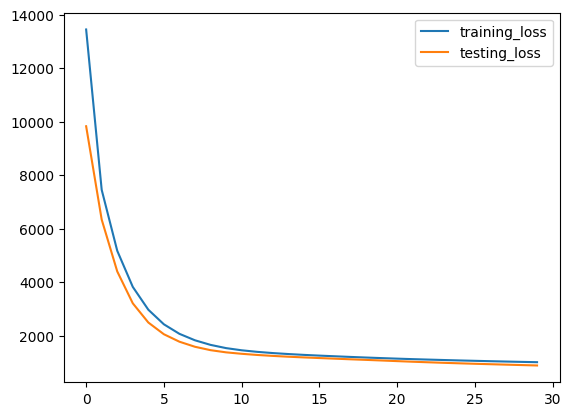

In [26]:
plt.plot( history_flat.history["loss"], label = "training_loss")
plt.plot( history_flat.history["val_loss"], label = "testing_loss")
plt.legend()

In [27]:
def plots_pred(model, data, test_data, conv=True):
    forecast=[]
    for time in range(split_index-WINDOW_SIZE,len(data) - WINDOW_SIZE):
      forecast.append(model.predict(data[time:time + WINDOW_SIZE][np.newaxis]))

    forecast = forecast[:]
    results = np.array(forecast)[:, 0, 0]
    if conv:
        results= np.squeeze(results)

    error = tf.keras.metrics.mean_absolute_error(test_data, results).numpy()
    plt.figure(figsize=(15, 6))

    plt.plot(list(range(split_index,len(data))), test_data, label = 'Test Data')
    plt.plot(list(range(split_index,len(data))), results, label = 'Predictions')
    plt.fill_between(range(split_index,len(data)), results - error, results + error, alpha = 0.3, color = 'grey',label=r'error 1-$\sigma$')
    plt.legend()
    plt.show()

1/1 [==============================] - 0s 22ms/step


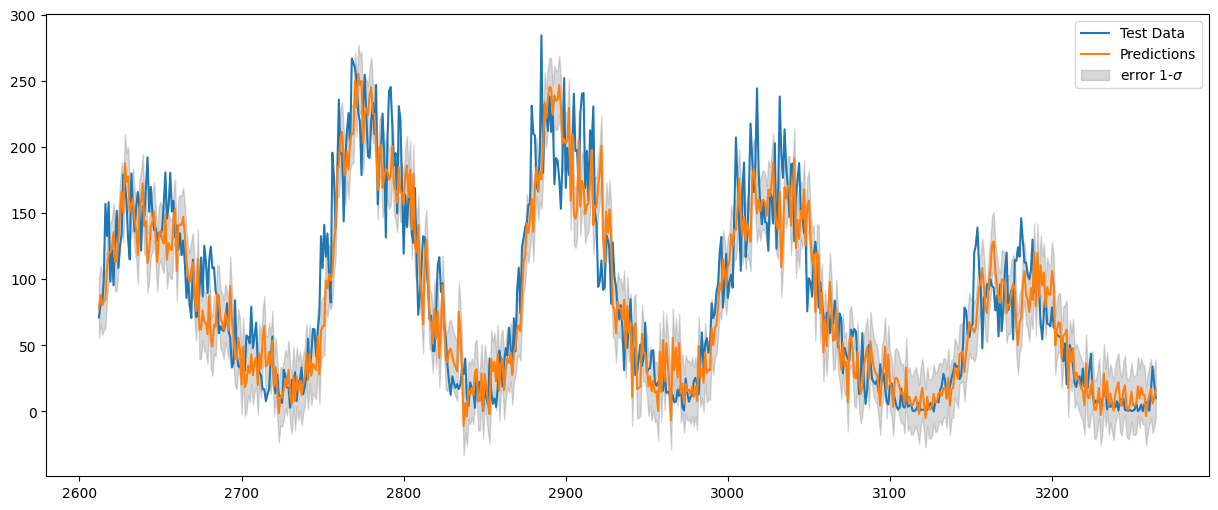

In [28]:
plots_pred(model_flat, data, test_data, conv=False)